In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMRegressor

In [ ]:
df = pd.read_csv("./csv_export/main_dataset.csv")

print(df.shape)
df.head()

C:\Users\maiaj\AppData\Local\Temp\ipykernel_10252\3255897821.py:3: DtypeWarning: Columns (14,27,29,32,41,42,46,47,48,49,51,56,57,58,59,60,61,78,79,82,87,91,92,94,96,98,100,135,139,142,143,147,148,149,150,151,152,153,154,162,163,164,165,166,168,169,170,174) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./csv_export/main_dataset.csv")


(364745, 207)


,IdMovementVinci,IdFarms,IdMovement,IdADL,IdPkgStand,IdTraficType,IdIrregularityCode,IdRunway,IdAircraftType,IdBusinessUnitType,...,snowfall_sum,windspeed_10m_max,day_of_week,is_weekend,season,dest_country,is_fr_public_holiday,is_fr_school_holiday_zone_a,is_dest_public_holiday,is_dest_school_holiday
0,ACA876|A|2025-04-14 08:35:00+00,1.016947e+09,20250414080700CGHKW,20250414103500ACA00876,D,1,NaN,17L,333,1,...,0.0,13.8,0,0,spring,CA,0,0,0,0
1,ACA876|A|2024-05-27 07:55:00+00,1.015952e+09,20240527072400CGHPX,20240527095500ACA00876,C,1,NaN,35R,788,1,...,0.0,12.7,0,0,spring,CA,0,0,0,0
2,ACA876|A|2024-01-14 10:00:00+00,1.015522e+09,20240114103200CGFAF,20240114110000ACA00876,D,1,NaN,17L,333,1,...,0.0,7.0,6,1,winter,CA,0,0,0,0
3,ACA876|A|2024-05-11 07:55:00+00,1.015909e+09,20240511070900CGHPX,20240511095500ACA00876,C,1,NaN,17L,788,1,...,0.0,15.5,5,1,spring,CA,0,0,0,0
4,AF1489|A|2025-10-03 17:45:00+00,1.017600e+09,20251003191200FHBLC,20251003194500AFR01489,L,1,RTD,17L,E90,1,...,0.0,4.8,4,0,autumn,NaN,0,0,0,0


In [3]:
TARGET = "NbPaxTotal"

BASE_FEATURES = [
    "IdAircraftType",
    "IdBusinessUnitType",
    "IdBusContactType",
    "IdTraficType",
    "airlineOACICode",
    "AirportPrevious",
    "ServiceCode",
    "FlightNumberNormalized",
    "LTScheduledDatetime",
    "Direction",
    "SysTerminal",
    "NbOfSeats",
    
    "day_of_week",
    "is_weekend",
    "season",
    "dest_country",
    "is_fr_public_holiday",
    "is_fr_school_holiday_zone_a",
    "is_dest_public_holiday",
    "is_dest_school_holiday",

    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "windspeed_10m_max",
]

df = df[BASE_FEATURES + [TARGET]].copy()

print(df.shape)
df.head()

(364745, 25)


,IdAircraftType,IdBusinessUnitType,IdBusContactType,IdTraficType,airlineOACICode,AirportPrevious,ServiceCode,FlightNumberNormalized,LTScheduledDatetime,Direction,...,dest_country,is_fr_public_holiday,is_fr_school_holiday_zone_a,is_dest_public_holiday,is_dest_school_holiday,precipitation_sum,rain_sum,snowfall_sum,windspeed_10m_max,NbPaxTotal
0,333,1,1,1,ACA,YUL,J,ACA00876,2025-04-14 10:35:00,Arrivée,...,CA,0,0,0,0,0.2,0.2,0.0,13.8,222.0
1,788,1,1,1,ACA,YUL,J,ACA00876,2024-05-27 09:55:00,Arrivée,...,CA,0,0,0,0,4.2,4.2,0.0,12.7,216.0
2,333,1,1,1,ACA,YUL,J,ACA00876,2024-01-14 11:00:00,Arrivée,...,CA,0,0,0,0,0.0,0.0,0.0,7.0,270.0
3,788,1,1,1,ACA,YUL,J,ACA00876,2024-05-11 09:55:00,Arrivée,...,CA,0,0,0,0,0.0,0.0,0.0,15.5,255.0
4,E90,1,3,1,AFR,NTE,J,AFR01489,2025-10-03 19:45:00,Arrivée,...,NaN,0,0,0,0,0.0,0.0,0.0,4.8,101.0


In [4]:
df["LTScheduledDatetime"] = pd.to_datetime(df["LTScheduledDatetime"], errors="coerce")

numeric_cols = [
    "IdAircraftType",
    "IdBusinessUnitType",
    "IdBusContactType",
    "IdTraficType",
    "NbOfSeats",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "windspeed_10m_max",
    TARGET
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

bool_cols = [
    "is_weekend",
    "is_fr_public_holiday",
    "is_fr_school_holiday_zone_a",
    "is_dest_public_holiday",
    "is_dest_school_holiday"
]

for col in bool_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.isna().sum().sort_values(ascending=False).head(30))

IdAircraftType                 198731
dest_country                   109692
NbPaxTotal                      52919
windspeed_10m_max               52383
snowfall_sum                    52383
rain_sum                        52383
precipitation_sum               52383
SysTerminal                      1908
FlightNumberNormalized           1881
NbOfSeats                         316
IdTraficType                        0
is_fr_public_holiday                0
is_dest_school_holiday              0
is_dest_public_holiday              0
is_fr_school_holiday_zone_a         0
season                              0
IdBusContactType                    0
airlineOACICode                     0
is_weekend                          0
IdBusinessUnitType                  0
Direction                           0
LTScheduledDatetime                 0
ServiceCode                         0
AirportPrevious                     0
day_of_week                         0
dtype: int64


In [5]:
df = df[df["IdTraficType"] != 0].copy()

print(df.shape)
print(df["IdTraficType"].value_counts(dropna=False).sort_index())

(351762, 25)
1    295380
2     56382
Name: IdTraficType, dtype: int64


In [6]:
df["year"] = df["LTScheduledDatetime"].dt.year
df["month"] = df["LTScheduledDatetime"].dt.month
df["day"] = df["LTScheduledDatetime"].dt.day
df["hour"] = df["LTScheduledDatetime"].dt.hour
df["minute"] = df["LTScheduledDatetime"].dt.minute
df["weekofyear"] = df["LTScheduledDatetime"].dt.isocalendar().week.astype("int")
df["is_month_start"] = df["LTScheduledDatetime"].dt.is_month_start.astype(int)
df["is_month_end"] = df["LTScheduledDatetime"].dt.is_month_end.astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["has_rain"] = (df["rain_sum"] > 0).astype(int)
df["has_snow"] = (df["snowfall_sum"] > 0).astype(int)
df["has_precipitation"] = (df["precipitation_sum"] > 0).astype(int)

df.head()

,IdAircraftType,IdBusinessUnitType,IdBusContactType,IdTraficType,airlineOACICode,AirportPrevious,ServiceCode,FlightNumberNormalized,LTScheduledDatetime,Direction,...,weekofyear,is_month_start,is_month_end,hour_sin,hour_cos,month_sin,month_cos,has_rain,has_snow,has_precipitation
0,333.0,1,1,1,ACA,YUL,J,ACA00876,2025-04-14 10:35:00,Arrivée,...,16,0,0,0.500000,-0.866025,0.866025,-0.500000,1,0,1
1,788.0,1,1,1,ACA,YUL,J,ACA00876,2024-05-27 09:55:00,Arrivée,...,22,0,0,0.707107,-0.707107,0.500000,-0.866025,1,0,1
2,333.0,1,1,1,ACA,YUL,J,ACA00876,2024-01-14 11:00:00,Arrivée,...,2,0,0,0.258819,-0.965926,0.500000,0.866025,0,0,0
3,788.0,1,1,1,ACA,YUL,J,ACA00876,2024-05-11 09:55:00,Arrivée,...,19,0,0,0.707107,-0.707107,0.500000,-0.866025,0,0,0
4,NaN,1,3,1,AFR,NTE,J,AFR01489,2025-10-03 19:45:00,Arrivée,...,40,0,0,-0.965926,0.258819,-0.866025,0.500000,0,0,0


In [21]:
df_known = df[df[TARGET].notna()].copy()
df_future = df[df[TARGET].isna()].copy()

print("df_known :", df_known.shape)
print("df_future:", df_future.shape)

df_known : (298843, 40)
df_future: (52919, 40)


In [22]:
train_end = "2024-12-31 23:59:59"
val_end = "2025-09-30 23:59:59"
test_end = "2026-03-22 23:59:59"

train_df = df_known[df_known["LTScheduledDatetime"] <= train_end].copy()
val_df = df_known[
    (df_known["LTScheduledDatetime"] > train_end) &
    (df_known["LTScheduledDatetime"] <= val_end)
].copy()
test_df = df_known[
    (df_known["LTScheduledDatetime"] > val_end) &
    (df_known["LTScheduledDatetime"] <= test_end)
].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print(train_df["LTScheduledDatetime"].min(), "->", train_df["LTScheduledDatetime"].max())
print(val_df["LTScheduledDatetime"].min(), "->", val_df["LTScheduledDatetime"].max())
print(test_df["LTScheduledDatetime"].min(), "->", test_df["LTScheduledDatetime"].max())

Train: (181360, 40)
Val  : (70961, 40)
Test : (42537, 40)
2023-01-01 00:05:00 -> 2024-12-31 23:00:00
2025-01-01 00:45:00 -> 2025-09-30 23:45:00
2025-10-01 00:15:00 -> 2026-03-22 23:55:00


In [23]:
def add_group_stat(train_base, df_to_enrich, group_cols, target_col, stat_name, agg="mean", fill_value=None):
    df_to_enrich = df_to_enrich.copy()

    if stat_name in df_to_enrich.columns:
        df_to_enrich = df_to_enrich.drop(columns=[stat_name])

    stats = (
        train_base
        .groupby(group_cols, dropna=False)[target_col]
        .agg(agg)
        .reset_index()
        .rename(columns={target_col: stat_name})
    )

    out = df_to_enrich.merge(stats, on=group_cols, how="left")

    if fill_value is not None:
        out[stat_name] = out[stat_name].fillna(fill_value)

    return out

In [24]:
global_mean = train_df[TARGET].mean()

group_features = [
    (["airlineOACICode"], "mean_pax_by_airline"),
    (["AirportPrevious"], "mean_pax_by_airport_previous"),
    (["ServiceCode"], "mean_pax_by_service"),
    (["SysTerminal"], "mean_pax_by_terminal"),
    (["day_of_week"], "mean_pax_by_dayofweek"),
    (["season"], "mean_pax_by_season"),
    (["IdAircraftType"], "mean_pax_by_aircraft"),
    (["airlineOACICode", "day_of_week"], "mean_pax_by_airline_day"),
    (["AirportPrevious", "day_of_week"], "mean_pax_by_airport_day"),
]

for cols, feat_name in group_features:
    train_df = add_group_stat(train_df, train_df, cols, TARGET, feat_name, agg="mean", fill_value=global_mean)
    val_df = add_group_stat(train_df, val_df, cols, TARGET, feat_name, agg="mean", fill_value=global_mean)
    test_df = add_group_stat(train_df, test_df, cols, TARGET, feat_name, agg="mean", fill_value=global_mean)

    if len(df_future) > 0:
        df_future = add_group_stat(train_df, df_future, cols, TARGET, feat_name, agg="mean", fill_value=global_mean)

In [25]:
for d in [train_df, val_df, test_df]:
    d["seat_fill_proxy"] = d["mean_pax_by_aircraft"] / np.clip(d["NbOfSeats"], 1, None)
    d["is_large_aircraft"] = (d["NbOfSeats"] >= 180).astype(int)
    d["is_small_aircraft"] = (d["NbOfSeats"] <= 100).astype(int)

if len(df_future) > 0:
    df_future["seat_fill_proxy"] = df_future["mean_pax_by_aircraft"] / np.clip(df_future["NbOfSeats"], 1, None)
    df_future["is_large_aircraft"] = (df_future["NbOfSeats"] >= 180).astype(int)
    df_future["is_small_aircraft"] = (df_future["NbOfSeats"] <= 100).astype(int)

In [26]:
categorical_cols = [
    "IdAircraftType",
    "IdBusinessUnitType",
    "IdBusContactType",
    "IdTraficType",
    "airlineOACICode",
    "AirportPrevious",
    "ServiceCode",
    "FlightNumberNormalized",
    "SysTerminal",
    "Direction",
    "season",
    "dest_country",
]

for col in categorical_cols:
    train_df[col] = train_df[col].astype("category")
    val_df[col] = val_df[col].astype("category")
    test_df[col] = test_df[col].astype("category")

    if len(df_future) > 0:
        df_future[col] = df_future[col].astype("category")

In [27]:
drop_cols = [TARGET, "LTScheduledDatetime"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

print("Nombre de features :", len(feature_cols))
feature_cols

Nombre de features : 50


['IdAircraftType',
 'IdBusinessUnitType',
 'IdBusContactType',
 'IdTraficType',
 'airlineOACICode',
 'AirportPrevious',
 'ServiceCode',
 'FlightNumberNormalized',
 'Direction',
 'SysTerminal',
 'NbOfSeats',
 'day_of_week',
 'is_weekend',
 'season',
 'dest_country',
 'is_fr_public_holiday',
 'is_fr_school_holiday_zone_a',
 'is_dest_public_holiday',
 'is_dest_school_holiday',
 'precipitation_sum',
 'rain_sum',
 'snowfall_sum',
 'windspeed_10m_max',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'weekofyear',
 'is_month_start',
 'is_month_end',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'has_rain',
 'has_snow',
 'has_precipitation',
 'mean_pax_by_airline',
 'mean_pax_by_airport_previous',
 'mean_pax_by_service',
 'mean_pax_by_terminal',
 'mean_pax_by_dayofweek',
 'mean_pax_by_season',
 'mean_pax_by_aircraft',
 'mean_pax_by_airline_day',
 'mean_pax_by_airport_day',
 'seat_fill_proxy',
 'is_large_aircraft',
 'is_small_aircraft']

In [28]:
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[TARGET].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET].copy()

In [29]:
model_lgbm = LGBMRegressor(
    objective="regression",
    n_estimators=2500,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=50,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model_lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",
    categorical_feature=categorical_cols
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,011663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4154
[LightGBM] [Info] Number of data points in the train set: 181360, number of used features: 49
[LightGBM] [Info] Start training from score 112,802024


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, min_child_samples=50,
              n_estimators=2500, n_jobs=-1, num_leaves=63,
              objective='regression', random_state=42, reg_alpha=1.0,
              reg_lambda=1.0, subsample=0.8)

In [30]:
def regression_metrics(y_true, y_pred, name="dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print()

In [31]:
val_pred_lgbm = model_lgbm.predict(X_val)
test_pred_lgbm = model_lgbm.predict(X_test)

regression_metrics(y_val, val_pred_lgbm, "Validation LightGBM")
regression_metrics(y_test, test_pred_lgbm, "Test LightGBM")

--- Validation LightGBM ---
MAE  : 16.0467
RMSE : 24.3649
R2   : 0.8441

--- Test LightGBM ---
MAE  : 17.2769
RMSE : 25.9534
R2   : 0.8228



In [32]:
test_scored_lgbm = test_df.copy()
test_scored_lgbm["pred_nbpaxtotal"] = np.round(np.clip(test_pred_lgbm, 0, None)).astype(int)
test_scored_lgbm["error"] = test_scored_lgbm["pred_nbpaxtotal"] - test_scored_lgbm[TARGET]
test_scored_lgbm["abs_error"] = np.abs(test_scored_lgbm["error"])

cols_view = [
    "LTScheduledDatetime",
    "FlightNumberNormalized",
    "airlineOACICode",
    "AirportPrevious",
    "NbOfSeats",
    TARGET,
    "pred_nbpaxtotal",
    "error",
    "abs_error"
]

test_scored_lgbm[cols_view]

,LTScheduledDatetime,FlightNumberNormalized,airlineOACICode,AirportPrevious,NbOfSeats,NbPaxTotal,pred_nbpaxtotal,error,abs_error
0,2025-10-03 19:45:00,AFR01489,AFR,NTE,100.0,101.0,77,-24.0,24.0
1,2025-10-24 19:50:00,AFR01541,AFR,MRS,90.0,66.0,60,-6.0,6.0
2,2025-10-20 11:00:00,AFR01697,AFR,NCE,76.0,69.0,57,-12.0,12.0
3,2025-10-23 11:00:00,AFR01697,AFR,NCE,76.0,64.0,58,-6.0,6.0
4,2026-02-09 11:50:00,AFR06023,AFR,TLS,76.0,34.0,63,29.0,29.0
...,...,...,...,...,...,...,...,...,...
42532,2026-02-11 14:25:00,SPC00314,TYW,HUY,13.0,1.0,2,1.0,1.0
42533,2026-02-02 15:15:00,AJD00214,AJD,SMV,9.0,2.0,17,15.0,15.0
42534,2026-01-04 15:00:00,APR00416,AXY,BQH,50.0,13.0,1,-12.0,12.0
42535,2026-03-01 19:00:00,SFS00091,SFS,LYS,14.0,0.0,9,9.0,9.0


In [23]:
test_scored_lgbm[cols_view].sort_values("abs_error", ascending=False).head(30)

,LTScheduledDatetime,FlightNumberNormalized,airlineOACICode,AirportPrevious,NbOfSeats,NbPaxTotal,pred_nbpaxtotal,error,abs_error
2472,2026-04-05 15:40:00,UAE00082,UAE,DXB,312.0,0.0,310,310.0,310.0
1433,2026-04-04 15:40:00,UAE00082,UAE,DXB,312.0,0.0,301,301.0,301.0
32631,2026-03-30 13:55:00,ACA00877,ACA,YUL,285.0,0.0,295,295.0,295.0
109,2026-03-29 13:55:00,ACA00877,ACA,YUL,297.0,0.0,294,294.0,294.0
1118,2026-04-05 11:00:00,TSC00573,TSC,YUL,332.0,0.0,292,292.0,292.0
435,2026-03-29 11:00:00,TSC00573,TSC,YUL,332.0,0.0,288,288.0,288.0
3605,2026-03-28 12:55:00,ACA00877,ACA,YUL,297.0,0.0,284,284.0,284.0
1972,2026-04-05 09:15:00,TSC00572,TSC,YUL,332.0,0.0,280,280.0,280.0
5761,2026-03-28 08:15:00,TSC00572,TSC,YUL,332.0,0.0,279,279.0,279.0
2658,2026-04-04 13:50:00,UAE00081,UAE,DXB,312.0,0.0,278,278.0,278.0


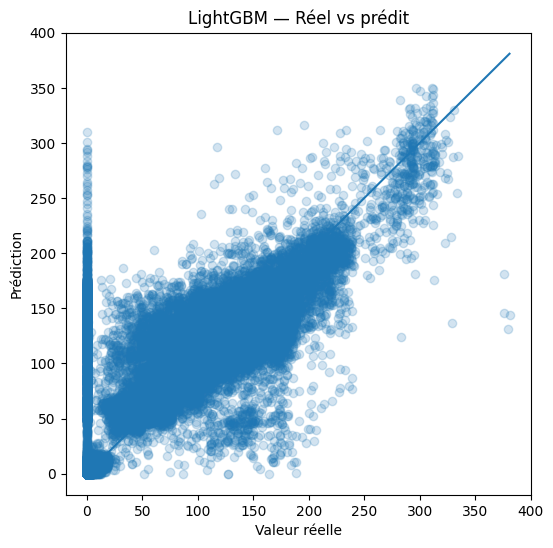

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(test_scored_lgbm[TARGET], test_scored_lgbm["pred_nbpaxtotal"], alpha=0.2)
plt.xlabel("Valeur réelle")
plt.ylabel("Prédiction")
plt.title("LightGBM — Réel vs prédit")

max_val = max(test_scored_lgbm[TARGET].max(), test_scored_lgbm["pred_nbpaxtotal"].max())
plt.plot([0, max_val], [0, max_val])
plt.show()

# Prophet

In [45]:
from prophet import Prophet

df_prophet = df_known.copy()
df_prophet["date"] = df_prophet["LTScheduledDatetime"].dt.date

df_daily = (
    df_prophet.groupby("date")[TARGET]
    .sum()
    .reset_index()
    .rename(columns={"date": "ds", TARGET: "y"})
)

df_daily["ds"] = pd.to_datetime(df_daily["ds"])

print(df_daily.shape)
#df_daily.head()
df_daily

(1194, 2)


,ds,y
0,2023-01-01,28276.0
1,2023-01-02,30356.0
2,2023-01-03,23855.0
3,2023-01-04,19833.0
4,2023-01-05,19720.0
...,...,...
1189,2026-04-04,0.0
1190,2026-04-05,0.0
1191,2026-04-06,0.0
1192,2026-04-07,0.0


In [39]:
train_prophet = df_daily[df_daily["ds"] <= "2025-09-30"].copy()
test_prophet = df_daily[(df_daily["ds"] > "2025-09-30") & (df_daily["ds"]<= test_end)].copy()

print(train_prophet.shape, test_prophet.shape)



(1004, 2) (173, 2)


In [40]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_prophet.fit(train_prophet)

15:31:19 - cmdstanpy - INFO - Chain [1] start processing
15:31:19 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
future_prophet = test_prophet[["ds"]].copy()
forecast_prophet = model_prophet.predict(future_prophet)

prophet_eval = test_prophet.merge(
    forecast_prophet[["ds", "yhat"]],
    on="ds",
    how="left"
)

prophet_eval["yhat"] = np.round(np.clip(prophet_eval["yhat"], 0, None)).astype(int)

prophet_eval

,ds,y,yhat
0,2025-10-01,30101.0,27202
1,2025-10-02,30109.0,30096
2,2025-10-03,30595.0,32131
3,2025-10-04,29141.0,31170
4,2025-10-05,34491.0,34491
...,...,...,...
168,2026-03-18,21344.0,23126
169,2026-03-19,27004.0,25902
170,2026-03-20,28413.0,27801
171,2026-03-21,30952.0,26687


In [42]:
regression_metrics(prophet_eval["y"], prophet_eval["yhat"], "Test Prophet")

--- Test Prophet ---
MAE  : 1976.7803
RMSE : 2620.7375
R2   : 0.7476



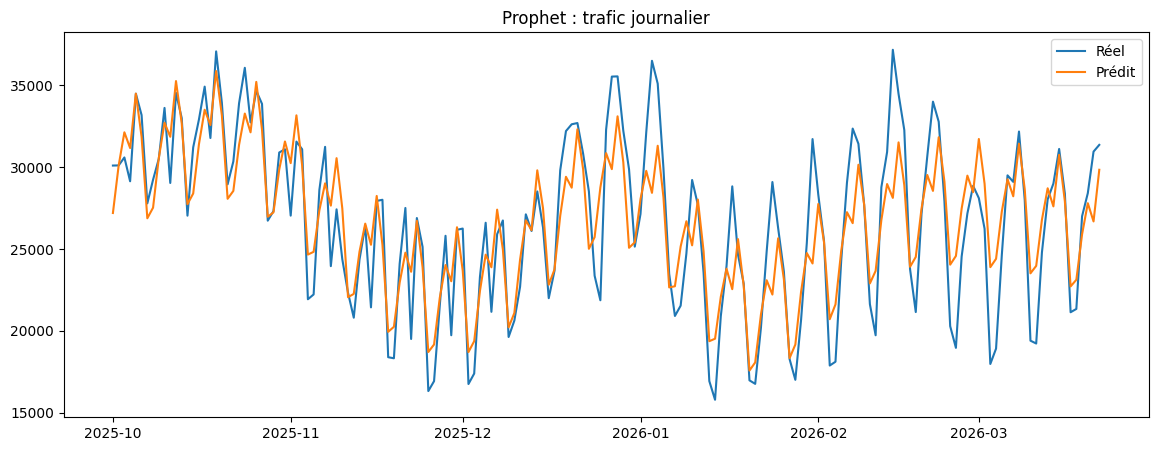

In [46]:
plt.figure(figsize=(14, 5))
plt.plot(prophet_eval["ds"], prophet_eval["y"], label="Réel")
plt.plot(prophet_eval["ds"], prophet_eval["yhat"], label="Prédit")
plt.title("Prophet : trafic journalier")
plt.legend()
plt.show()